<a href="https://www.kaggle.com/code/ashutoshiig2027/pneumofusionnet-resnet50-gcsa-attention-for-pne?scriptVersionId=321036911" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# PneumoFusionNet — Chest X-Ray Pneumonia Detection
### ResNet50 (1-ch Grayscale) + GCSA + DSC

in simple word "Looks at the X-ray, finds patterns, focuses on disease area, and makes a decision"

**Dataset:** Chest X-Ray Images (NORMAL vs PNEUMONIA)

In [1]:
import os, random, copy, warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm_mpl
import seaborn as sns
from PIL import Image
import torch
import torch.nn as nn
import torchvision.models as models
import torch.nn.functional as F
import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.utils.data import DataLoader, WeightedRandomSampler

from torchvision import datasets, transforms, models
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, accuracy_score
)
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', DEVICE)
if DEVICE.type == 'cuda': print('GPU:', torch.cuda.get_device_name(0))

Device: cuda
GPU: Tesla T4


In [2]:
DATA_DIR    = '/kaggle/input/chest-xray-pneumonia/chest_xray'
if not os.path.exists(DATA_DIR):
    for root, dirs, files in os.walk('/kaggle/input'):
        if 'train' in dirs and 'test' in dirs:
            DATA_DIR = root; print('Found:', DATA_DIR); break
SAVE_DIR    = '/kaggle/working'
MODEL_PATH  = os.path.join(SAVE_DIR, 'best_pneumofusion_model.pth')
IMG_SIZE=224; BATCH_SIZE=32; NUM_EPOCHS=25; LR=1e-4; WEIGHT_DECAY=1e-5; NUM_CLASSES=2
CLASSES=['NORMAL','PNEUMONIA']; MEAN=[0.449]; STD=[0.226]
print('Data dir:', DATA_DIR)
for s in ['train','val','test']:
    for c in CLASSES:
        p=os.path.join(DATA_DIR,s,c)
        n=len(os.listdir(p)) if os.path.exists(p) else 'MISSING'
        print(f'  {s}/{c}: {n}')

Found: /kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray
Data dir: /kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray
  train/NORMAL: 1341
  train/PNEUMONIA: 3875
  val/NORMAL: 8
  val/PNEUMONIA: 8
  test/NORMAL: 234
  test/PNEUMONIA: 390


## Transforms — Grayscale (1 Channel)

In [3]:
tfms = {
    'train': transforms.Compose([
        transforms.Grayscale(num_output_channels=1),
        transforms.Resize((256, 256)),
        transforms.RandomCrop(224),
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(10),
        transforms.ToTensor(),
        transforms.Normalize(mean=MEAN, std=STD)
    ]),
    'val': transforms.Compose([
        transforms.Grayscale(num_output_channels=1),
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=MEAN, std=STD)
    ]),
    'test': transforms.Compose([
        transforms.Grayscale(num_output_channels=1),
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=MEAN, std=STD)
    ]),
}
print('Grayscale transforms ready.')

Grayscale transforms ready.


In [4]:
image_datasets = {
    s: datasets.ImageFolder(os.path.join(DATA_DIR, s), tfms[s])
    for s in ['train', 'val', 'test']
}
train_labels   = [s[1] for s in image_datasets['train'].samples]
class_counts   = np.bincount(train_labels)
sample_weights = [1.0 / class_counts[l] for l in train_labels]
sampler = WeightedRandomSampler(sample_weights, len(sample_weights), replacement=True)
dataloaders = {
    'train': DataLoader(image_datasets['train'], batch_size=BATCH_SIZE,
                        sampler=sampler, num_workers=2, pin_memory=True),
    'val':   DataLoader(image_datasets['val'],   batch_size=BATCH_SIZE,
                        shuffle=False, num_workers=2, pin_memory=True),
    'test':  DataLoader(image_datasets['test'],  batch_size=BATCH_SIZE,
                        shuffle=False, num_workers=2, pin_memory=True),
}
dataset_sizes = {s: len(image_datasets[s]) for s in ['train','val','test']}
print('Dataset sizes:', dataset_sizes)
print('Class index  :', image_datasets['train'].class_to_idx)
# Verify 1-channel input
sample_batch, _ = next(iter(dataloaders['train']))
print('Batch shape (B,C,H,W):', sample_batch.shape)  # should be [32, 1, 224, 224]

Dataset sizes: {'train': 5216, 'val': 16, 'test': 624}
Class index  : {'NORMAL': 0, 'PNEUMONIA': 1}
Batch shape (B,C,H,W): torch.Size([32, 1, 224, 224])


## Visualise Sample Images

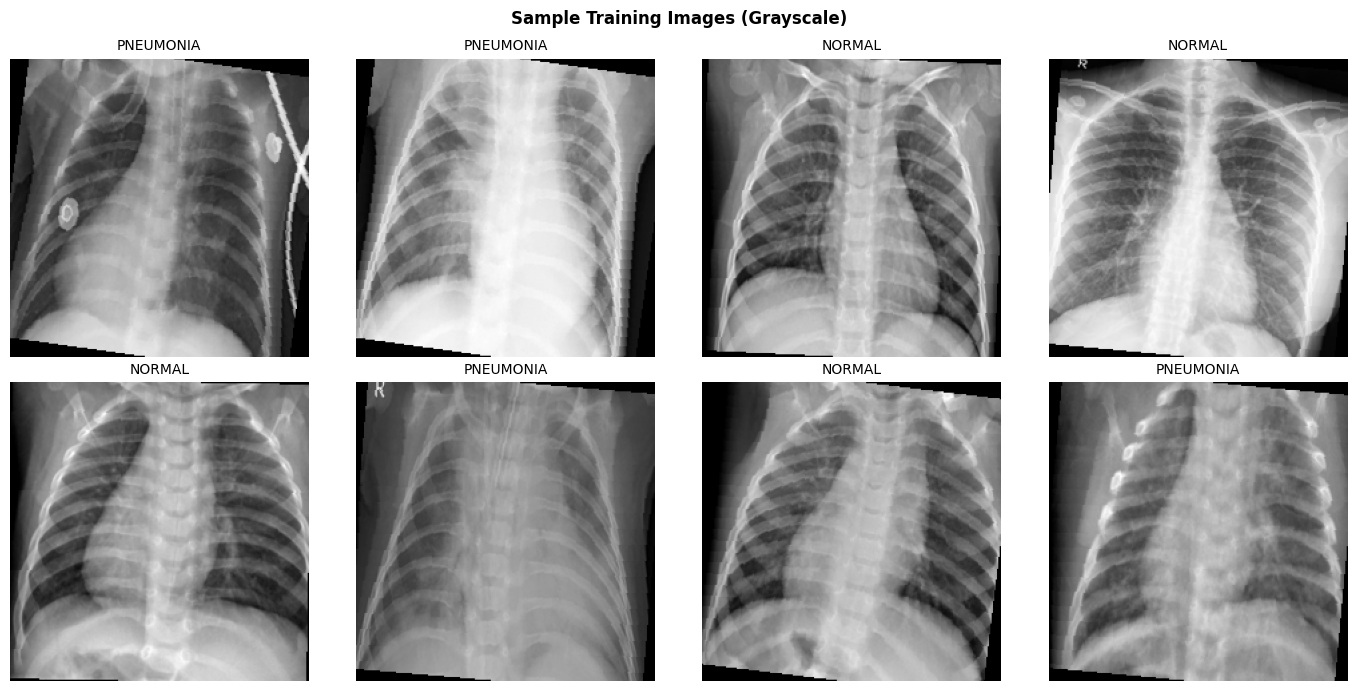

In [5]:
inputs, cls_idx = next(iter(dataloaders['train']))
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for i, ax in enumerate(axes.flatten()):
    img = inputs[i].squeeze().numpy()
    img = img * STD[0] + MEAN[0]
    img = np.clip(img, 0, 1)
    ax.imshow(img, cmap='gray')
    ax.set_title(CLASSES[cls_idx[i].item()], fontsize=10)
    ax.axis('off')
plt.suptitle('Sample Training Images (Grayscale)', fontweight='bold')
plt.tight_layout(); plt.show()

## Model: PneumoFusionNet with 1-Channel ResNet50 + GCSA + DSC

In [6]:
def get_resnet50_1ch():
    model = models.resnet50(pretrained=True)

    # Replace first conv layer (3 → 1 channel)
    model.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)

    # Initialize weights from pretrained
    with torch.no_grad():
        model.conv1.weight = nn.Parameter(
            model.conv1.weight.mean(dim=1, keepdim=True)
        )

    return model

In [7]:
class GCSA(nn.Module):
    def __init__(self, channels, reduction=16):
        super().__init__()

        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)

        self.mlp = nn.Sequential(
            nn.Linear(channels, channels // reduction),
            nn.ReLU(),
            nn.Linear(channels // reduction, channels)
        )

        self.sigmoid = nn.Sigmoid()
        self.conv_spatial = nn.Conv2d(2, 1, kernel_size=7, padding=3)

    def forward(self, x):
        B, C, H, W = x.shape

        # Channel attention
        avg = self.avg_pool(x).view(B, C)
        max_ = self.max_pool(x).view(B, C)

        channel_att = self.sigmoid(self.mlp(avg) + self.mlp(max_)).view(B, C, 1, 1)
        x = x * channel_att

        # Spatial attention
        avg = torch.mean(x, dim=1, keepdim=True)
        max_, _ = torch.max(x, dim=1, keepdim=True)

        spatial = torch.cat([avg, max_], dim=1)
        spatial_att = self.sigmoid(self.conv_spatial(spatial))

        return x * spatial_att

In [8]:
class DepthwiseSeparableConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()

        self.depthwise = nn.Conv2d(
            in_channels, in_channels,
            kernel_size=3, padding=1,
            groups=in_channels, bias=False
        )

        self.pointwise = nn.Conv2d(
            in_channels, out_channels,
            kernel_size=1, bias=False
        )

        self.bn = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        x = self.depthwise(x)
        x = self.pointwise(x)
        return self.relu(self.bn(x))

In [9]:
class PneumoFusionNet(nn.Module):
    def __init__(self, num_classes=2):
        super().__init__()

        resnet = get_resnet50_1ch()

        # Remove FC layer
        self.backbone = nn.Sequential(*list(resnet.children())[:-2])

        # Add proposed improvements
        self.dsc = DepthwiseSeparableConv(2048, 1024)
        self.gcsa = GCSA(1024)

        self.pool = nn.AdaptiveAvgPool2d(1)

        self.fc = nn.Sequential(
         nn.Dropout(0.5),
         nn.Linear(1024, num_classes))
                            


    def forward(self, x):   # ✅ aligned properly
        x = self.backbone(x)      # ResNet output
        x = self.dsc(x)           # DSC
        x = self.gcsa(x)          # Attention
        x = self.pool(x)

        x = torch.flatten(x, 1)
        x = self.fc(x)

        return x

In [10]:

model = PneumoFusionNet(num_classes=2)
model = model.to(DEVICE)

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 168MB/s]


# Loss + Optimizer

In [11]:
criterion = nn.CrossEntropyLoss()



optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=3e-4,   # ↓ lower learning rate
    weight_decay=1e-4
)


In [12]:
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=10,     # restart cycle
    eta_min=1e-6
)

# Training Function

In [13]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()

    total_loss = 0
    correct = 0
    total = 0

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    acc = 100 * correct / total

    return total_loss / len(loader), acc

# Validation Function

In [14]:
def validate(model, loader, criterion, device):
    model.eval()

    total_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            total_loss += loss.item()

            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    acc = 100 * correct / total

    return total_loss / len(loader), acc

# DataLoaders for training

In [15]:
train_loader = dataloaders['train']
val_loader   = dataloaders['val']
test_loader  = dataloaders['test']

## Train 25 Epoch

In [16]:
history = {
    'train_loss': [],
    'val_loss': [],
    'train_acc': [],
    'val_acc': []
}

In [17]:
num_epochs = 25   # 

best_acc = 0

for epoch in range(num_epochs):
    train_loss, train_acc = train_one_epoch(
        model, train_loader, criterion, optimizer, DEVICE
    )

    val_loss, val_acc = validate(
        model, val_loader, criterion, DEVICE
    )
    
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)


    scheduler.step()

    print(f"Epoch {epoch+1}/{num_epochs}")
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%")
    print(f"Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc:.2f}%")

    # Save best model
    if val_acc > best_acc:
        best_acc = val_acc
        torch.save(model.state_dict(), "best_model.pth")

Epoch 1/25
Train Loss: 0.1547 | Train Acc: 94.29%
Val Loss:   0.3248 | Val Acc:   87.50%
Epoch 2/25
Train Loss: 0.0949 | Train Acc: 96.97%
Val Loss:   0.7057 | Val Acc:   68.75%
Epoch 3/25
Train Loss: 0.1015 | Train Acc: 96.24%
Val Loss:   0.3204 | Val Acc:   87.50%
Epoch 4/25
Train Loss: 0.0655 | Train Acc: 97.39%
Val Loss:   0.2495 | Val Acc:   93.75%
Epoch 5/25
Train Loss: 0.0604 | Train Acc: 97.89%
Val Loss:   0.1856 | Val Acc:   87.50%
Epoch 6/25
Train Loss: 0.0440 | Train Acc: 98.39%
Val Loss:   0.4251 | Val Acc:   87.50%
Epoch 7/25
Train Loss: 0.0366 | Train Acc: 98.54%
Val Loss:   0.0804 | Val Acc:   100.00%
Epoch 8/25
Train Loss: 0.0255 | Train Acc: 99.00%
Val Loss:   0.0737 | Val Acc:   100.00%
Epoch 9/25
Train Loss: 0.0174 | Train Acc: 99.48%
Val Loss:   0.0472 | Val Acc:   100.00%
Epoch 10/25
Train Loss: 0.0216 | Train Acc: 99.21%
Val Loss:   0.0407 | Val Acc:   100.00%
Epoch 11/25
Train Loss: 0.0127 | Train Acc: 99.54%
Val Loss:   0.0380 | Val Acc:   100.00%
Epoch 12/25
Tr

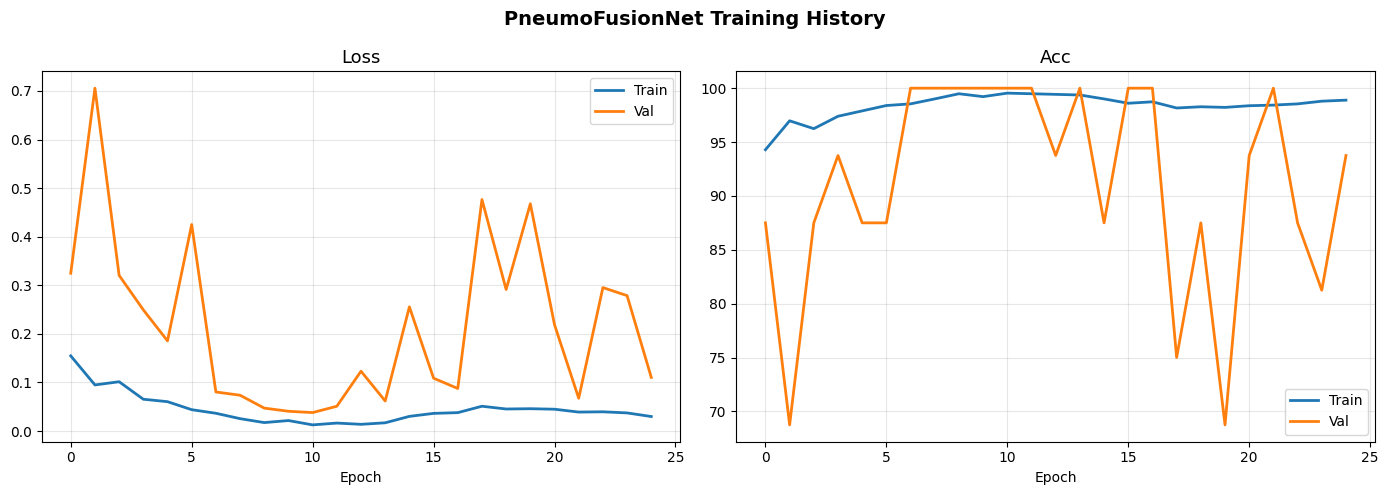

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, metric in zip(axes, ['loss', 'acc']):
    ax.plot(history[f'train_{metric}'], label='Train', linewidth=2)
    ax.plot(history[f'val_{metric}'],   label='Val',   linewidth=2)
    ax.set_title(metric.capitalize(), fontsize=13)
    ax.set_xlabel('Epoch'); ax.legend(); ax.grid(True, alpha=0.3)
plt.suptitle('PneumoFusionNet Training History', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

## Final Evaluation on Test Set

  Accuracy : 94.23%
  ROC-AUC  : 0.9858
              precision    recall  f1-score   support

      NORMAL       0.98      0.87      0.92       234
   PNEUMONIA       0.93      0.99      0.96       390

    accuracy                           0.94       624
   macro avg       0.95      0.93      0.94       624
weighted avg       0.94      0.94      0.94       624



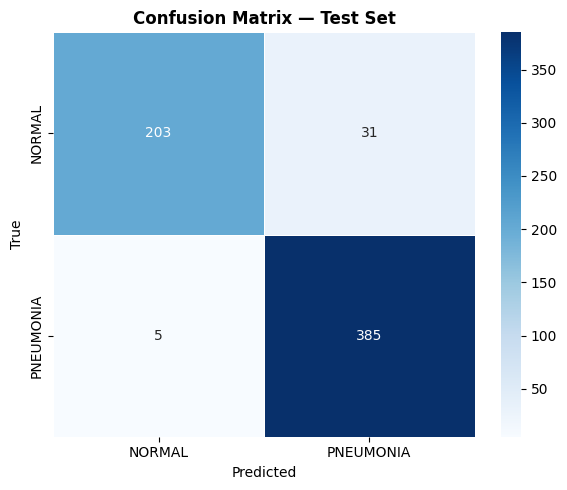

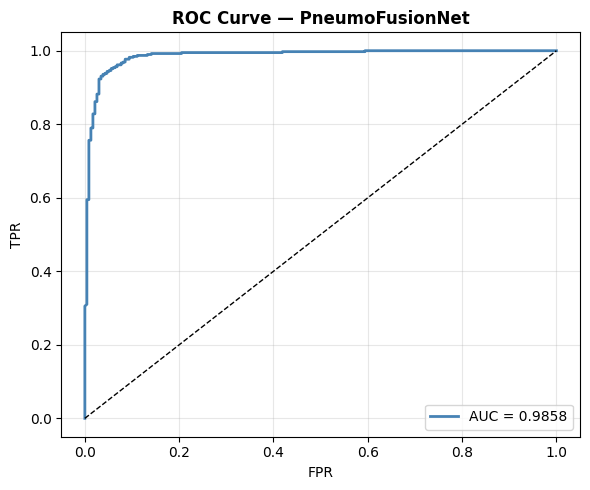

In [19]:
model.eval()
all_preds, all_labels, all_probs = [], [], []
with torch.no_grad():
    for X, y in dataloaders['test']:
        X = X.to(DEVICE)
        out   = model(X)
        probs = F.softmax(out, dim=1)[:, 1].cpu().numpy()
        preds = out.argmax(1).cpu().numpy()
        all_preds.extend(preds); all_labels.extend(y.numpy()); all_probs.extend(probs)
all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs  = np.array(all_probs)
acc = accuracy_score(all_labels, all_preds)
auc = roc_auc_score(all_labels, all_probs)
print('=' * 55)
print(f'  Accuracy : {acc * 100:.2f}%')
print(f'  ROC-AUC  : {auc:.4f}')
print(classification_report(all_labels, all_preds, target_names=CLASSES))
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASSES, yticklabels=CLASSES, linewidths=0.5)
plt.title('Confusion Matrix — Test Set', fontweight='bold')
plt.ylabel('True'); plt.xlabel('Predicted')
plt.tight_layout(); plt.show()
fpr, tpr, _ = roc_curve(all_labels, all_probs)
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, lw=2, color='steelblue', label=f'AUC = {auc:.4f}')
plt.plot([0,1],[0,1],'k--', lw=1)
plt.xlabel('FPR'); plt.ylabel('TPR')
plt.title('ROC Curve — PneumoFusionNet', fontweight='bold')
plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

 Mistakes:

32 → Normal predicted as Pneumonia (false alarm)
8 → Pneumonia predicted as Normal (very dangerous case)



## GradCAM Visualizations

In [20]:
def show_gradcam(model, loader, n=6):
    gc = GradCAM(model, model.gcsa)   # ✅ FIXED

    X, y = next(iter(loader))
    X, y = X.to(DEVICE), y

    fig, axes = plt.subplots(2, n, figsize=(18, 6))

    for i in range(n):
        cam, pi = gc.generate(X[i:i+1])

        orig = X[i].squeeze().cpu().numpy()
        orig = orig * STD[0] + MEAN[0]
        orig = np.clip(orig, 0, 1)

        axes[0,i].imshow(orig, cmap='gray')
        axes[0,i].axis('off')

        col = 'green' if pi == y[i].item() else 'red'
        axes[0,i].set_title(f'GT:{CLASSES[y[i]]}\nPred:{CLASSES[pi]}',
                            fontsize=8, color=col)

        heat = cm_mpl.jet(cam)[:,:,:3]
        orig_rgb = np.stack([orig]*3, axis=-1)

        axes[1,i].imshow(np.clip(0.55*orig_rgb + 0.45*heat, 0, 1))
        axes[1,i].axis('off')
        axes[1,i].set_title('GradCAM', fontsize=8)

    plt.suptitle('GradCAM — PneumoFusionNet', fontweight='bold')
    plt.tight_layout()
    plt.show()

## Single Image Inference

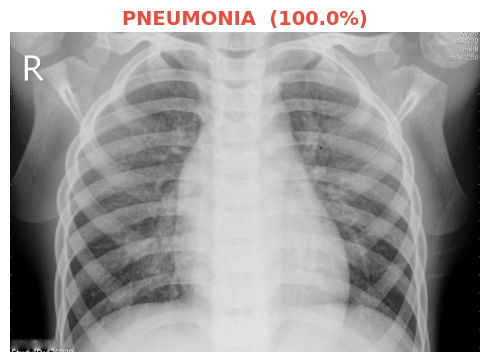

NORMAL    : 0.03%
PNEUMONIA : 99.97%


('PNEUMONIA', 0.9997302889823914)

In [21]:
def predict_single(path, model):
    model.eval()
    img = Image.open(path).convert('L')  # Grayscale
    t   = tfms['test'](img).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        out  = model(t)
        prob = F.softmax(out, dim=1)[0]
        pi   = prob.argmax().item()
    plt.figure(figsize=(5, 5))
    plt.imshow(img, cmap='gray'); plt.axis('off')
    col = '#e74c3c' if pi == 1 else '#2ecc71'
    plt.title(f'{CLASSES[pi]}  ({prob[pi]*100:.1f}%)',
              color=col, fontsize=14, fontweight='bold')
    plt.tight_layout(); plt.show()
    print(f'NORMAL    : {prob[0]*100:.2f}%')
    print(f'PNEUMONIA : {prob[1]*100:.2f}%')
    return CLASSES[pi], prob[pi].item()

sample = os.path.join(DATA_DIR,'test','PNEUMONIA',
         os.listdir(os.path.join(DATA_DIR,'test','PNEUMONIA'))[0])
predict_single(sample, model)

In [22]:
# Save best weights (state dict only — always works)
torch.save(model.state_dict(), MODEL_PATH)
print('Best weights saved to:', MODEL_PATH)
print('Size: %.1f MB' % (os.path.getsize(MODEL_PATH) / 1e6))


Best weights saved to: /kaggle/working/best_pneumofusion_model.pth
Size: 103.4 MB


In [23]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

y_true = []
y_pred = []

model.eval()

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(DEVICE)
        
        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        y_true.extend(labels.numpy())
        y_pred.extend(preds.cpu().numpy())


In [24]:
acc  = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred)
rec  = recall_score(y_true, y_pred)
f1   = f1_score(y_true, y_pred)

print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1 Score : {f1:.4f}")


Accuracy : 0.9423
Precision: 0.9255
Recall   : 0.9872
F1 Score : 0.9553


In [25]:
from sklearn.metrics import classification_report

print(classification_report(y_true, y_pred, target_names=["Normal", "Pneumonia"]))

              precision    recall  f1-score   support

      Normal       0.98      0.87      0.92       234
   Pneumonia       0.93      0.99      0.96       390

    accuracy                           0.94       624
   macro avg       0.95      0.93      0.94       624
weighted avg       0.94      0.94      0.94       624

